### 22101180 서종우 Data Analysis Term Project

파이썬 라이브러리 import

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

ISLP 라이브러리 import

In [2]:
from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize
import statsmodels.api as sm
from ISLP import confusion_table
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

파이썬 라이브러리를 통한 주식 데이터 다운로드

In [3]:
# 종목 리스트 (삼성전자, SK하이닉스, LG에너지솔루션, 삼성바이오로직스, 현대차)
tickers = ['005930.KS', '000660.KS', '373220.KS', '207940.KS', '005380.KS']

# 데이터 수집 (최근 1년)
data = yf.download(tickers, start='2020-01-01')
data.to_csv("코스피_상위_5.csv")
print(data.head())

[*********************100%***********************]  5 of 5 completed

Price              Close                                                     \
Ticker         000660.KS     005380.KS     005930.KS    207940.KS 373220.KS   
Date                                                                          
2020-01-02  88898.843750  94165.195312  47372.843750  651914.0625       NaN   
2020-01-03  88711.085938  92569.171875  47630.292969  642025.0625       NaN   
2020-01-06  88523.343750  92569.171875  47630.292969  626811.1875       NaN   
2020-01-07  88241.703125  92170.156250  47887.769531  637460.9375       NaN   
2020-01-08  91433.429688  89377.125000  48745.972656  621486.3750       NaN   

Price               High                                                     \
Ticker         000660.KS     005380.KS     005930.KS    207940.KS 373220.KS   
Date                                                                          
2020-01-02  90306.956375  96559.225702  48059.406703  668649.3125       NaN   
2020-01-03  91902.807548  94963.202182  48574.31679

편의를 위한 5개 종목 list 정의 및 데이터 프레임 생성

In [4]:
# 데이터 불러오기 (헤더가 두 줄이므로 header=[0, 1]로 설정합니다)
df = pd.read_csv('코스피_상위_5.csv', header=[0, 1], index_col=0)

# 분석하기 편하도록 종목 리스트 정의
tickers = ['005930.KS', '000660.KS', '373220.KS', '207940.KS', '005380.KS']
ticker_names = {
    '005930.KS': 'Samsung',
    '000660.KS': 'SK_Hynix',
    '373220.KS': 'LG_Energy',
    '207940.KS': 'Samsung_Bio',
    '005380.KS': 'Hyundai_Motor'
}

# 종목별 개별 데이터 프레임 생성
stocks = {}
for ticker in tickers:
    # 'Ticker' 레벨에서 해당 종목코드만 추출하여 stocks 딕셔너리에 저장
    stocks[ticker_names[ticker]] = df.xs(ticker, axis=1, level='Ticker').dropna()

종목별 데이터 시각화(일반적인 캔들 차트에서 종가만 나타낸다.)

 [Samsung] 데이터 파악하기

[1] 데이터 앞부분 (Head) - 상위 5일치
Price               Open          High           Low         Close    Volume
Date                                                                        
2020-01-02  47630.304857  48059.406703  47201.203012  47372.843750  12993228
2020-01-03  48059.394707  48574.316793  47115.370883  47630.292969  15422255
2020-01-06  47115.370883  47716.113316  46857.909840  47630.292969  10278951
2020-01-07  47801.949156  48402.691784  47716.128780  47887.769531  10009778
2020-01-08  48231.050410  49260.894903  47973.589287  48745.972656  23501171

[2] 기초 통계량 (Describe)
Price          Close        Volume
count    1560.000000  1.560000e+03
mean    71123.436368  1.867441e+07
std     33134.764587  9.427691e+06
min     36473.652344  0.000000e+00
25%     55080.970703  1.274007e+07
50%     64268.164062  1.656032e+07
75%     72586.968750  2.263028e+07
max    296000.000000  9.030618e+07

[3] 상관관계 행렬 (Correlation)
Price      Close      High       Low      Open 

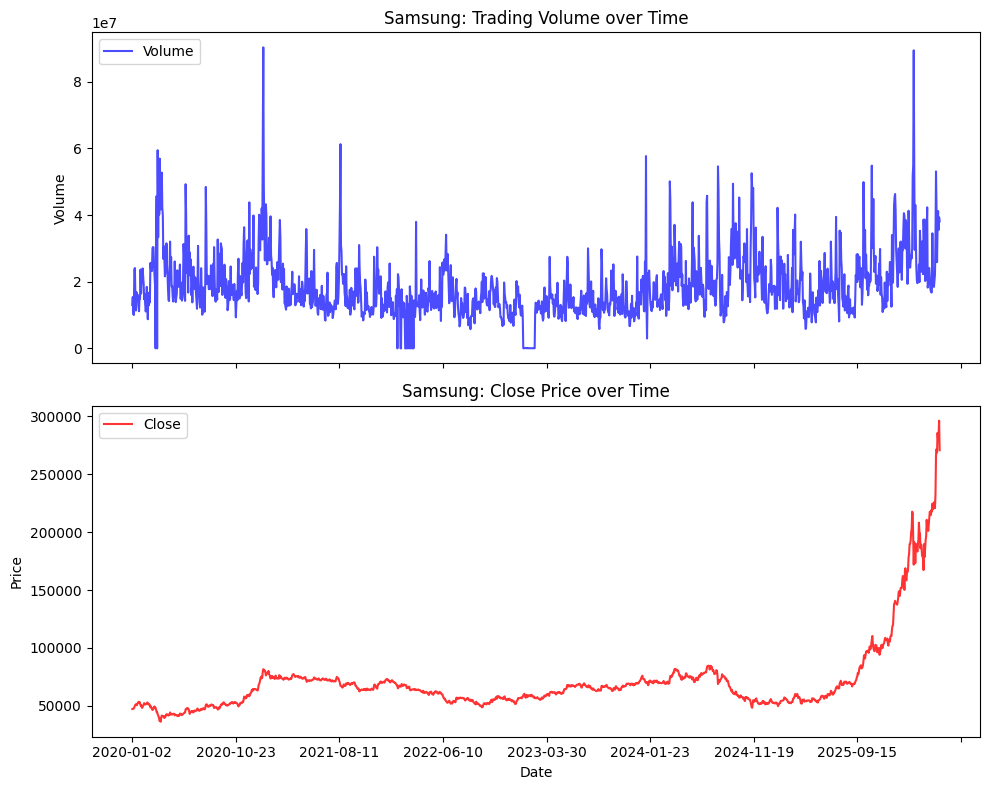

 [SK_Hynix] 데이터 파악하기

[1] 데이터 앞부분 (Head) - 상위 5일치
Price               Open          High           Low         Close   Volume
Date                                                                       
2020-01-02  90119.208025  90306.956375  88335.598700  88898.843750  2342070
2020-01-03  90588.569238  91902.807548  88523.337607  88711.085938  3021380
2020-01-06  87302.979520  89462.085465  87115.231177  88523.343750  2577573
2020-01-07  88711.073886  89555.941257  88241.703125  88241.703125  2489429
2020-01-08  90494.688110  93404.787001  89368.198216  91433.429688  7014748

[2] 기초 통계량 (Describe)
Price         Close        Volume
count  1.560000e+03  1.560000e+03
mean   1.972996e+05  3.828358e+06
std    2.345150e+05  1.922261e+06
min    6.477318e+04  0.000000e+00
25%    9.149507e+04  2.637619e+06
50%    1.180730e+05  3.473724e+06
75%    1.849470e+05  4.569203e+06
max    1.976000e+06  1.915065e+07

[3] 상관관계 행렬 (Correlation)
Price      Close      High       Low      Open    Volume
Price

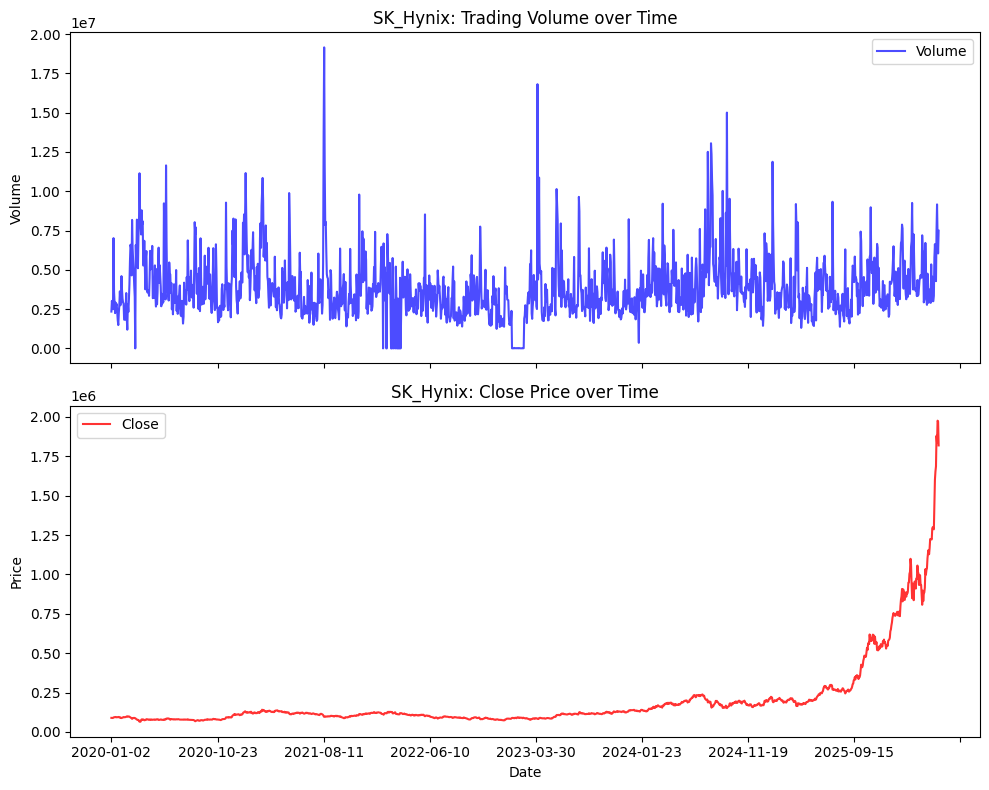

 [LG_Energy] 데이터 파악하기

[1] 데이터 앞부분 (Head) - 상위 5일치
Price           Open      High       Low     Close      Volume
Date                                                          
2022-01-27  597000.0  598000.0  450000.0  505000.0  15946992.0
2022-01-28  476000.0  483000.0  445000.0  450000.0   4559773.0
2022-02-03  458000.0  495500.0  441000.0  477000.0   2918435.0
2022-02-04  476500.0  505000.0  476000.0  504000.0   2088996.0
2022-02-07  520000.0  548000.0  511000.0  548000.0   1911176.0

[2] 기초 통계량 (Describe)
Price          Close        Volume
count    1047.000000  1.047000e+03
mean   427136.103152  3.596725e+05
std     78576.741820  5.784343e+05
min    268000.000000  0.000000e+00
25%    372000.000000  1.919300e+05
50%    411000.000000  2.769100e+05
75%    475750.000000  3.916845e+05
max    624000.000000  1.594699e+07

[3] 상관관계 행렬 (Correlation)
Price      Close      High       Low      Open    Volume
Price                                                   
Close   1.000000  0.995924  0

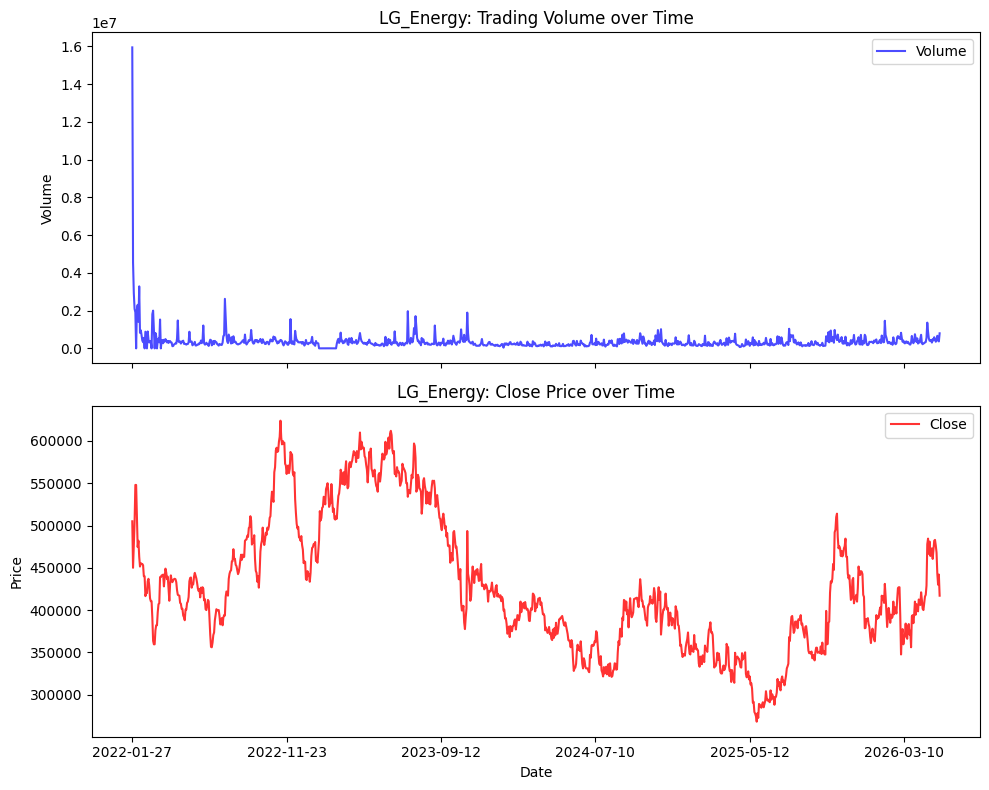

 [Samsung_Bio] 데이터 파악하기

[1] 데이터 앞부분 (Head) - 상위 5일치
Price              Open         High          Low        Close  Volume
Date                                                                  
2020-01-02  658760.3125  668649.3125  647349.9375  651914.0625   71172
2020-01-03  656478.2500  664085.1875  636700.2500  642025.0625   81379
2020-01-06  630614.6875  633657.4375  625289.8125  626811.1875   65715
2020-01-07  632136.0625  638221.6250  625289.8125  637460.9375   56300
2020-01-08  627571.8750  631375.3750  610075.9375  621486.3750   99886

[2] 기초 통계량 (Describe)
Price         Close        Volume
count  1.560000e+03  1.560000e+03
mean   1.305144e+06  6.715340e+04
std    2.429995e+05  8.677351e+04
min    5.568274e+05  0.000000e+00
25%    1.179290e+06  3.079600e+04
50%    1.256665e+06  4.519750e+04
75%    1.473374e+06  7.198100e+04
max    1.965000e+06  1.996580e+06

[3] 상관관계 행렬 (Correlation)
Price      Close      High       Low      Open    Volume
Price                                

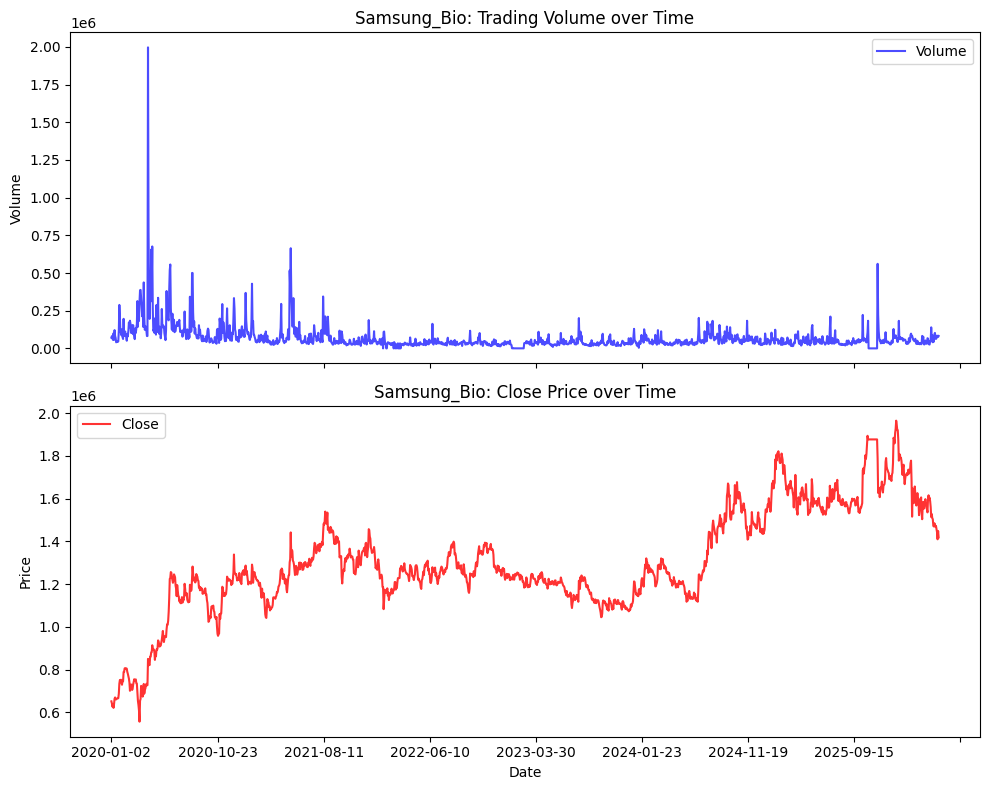

 [Hyundai_Motor] 데이터 파악하기

[1] 데이터 앞부분 (Head) - 상위 5일치
Price               Open          High           Low         Close   Volume
Date                                                                       
2020-01-02  96559.225702  96559.225702  94165.195312  94165.195312   556532
2020-01-03  94564.197131  94963.202182  91771.161773  92569.171875  1145187
2020-01-06  92569.171875  93367.181977  92170.166824  92569.171875   334574
2020-01-07  92968.166261  93367.171266  92170.156250  92170.156250   674196
2020-01-08  91771.155134  92170.160156  88978.119978  89377.125000  1044825

[2] 기초 통계량 (Describe)
Price          Close        Volume
count    1560.000000  1.560000e+03
mean   191506.954307  1.111153e+06
std     90673.695549  1.167181e+06
min     52588.863281  0.000000e+00
25%    150387.921875  5.287175e+05
50%    173414.468750  7.744625e+05
75%    205705.000000  1.231142e+06
max    712000.000000  1.993370e+07

[3] 상관관계 행렬 (Correlation)
Price      Close      High       Low      Open  

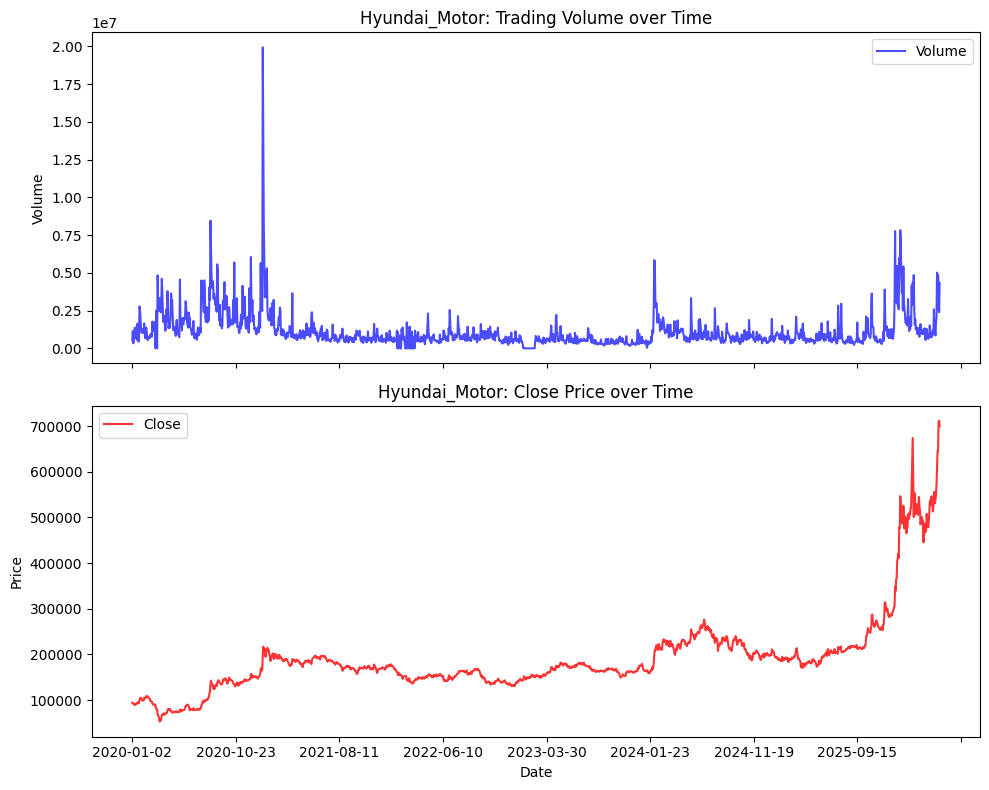

In [5]:
# 5개 종목을 순회하며 기초 통계량 및 시각화 진행
for name, data in stocks.items():
    print(f" [{name}] 데이터 파악하기")

    # 1. 데이터의 형태 (Data Head)
    print("\n[1] 데이터 앞부분 (Head) - 상위 5일치")
    # 공간 절약을 위해 주요 컬럼만 출력
    print(data[['Open', 'High', 'Low', 'Close', 'Volume']].head())

    # 2. 기초 통계량 (Data Distribution)
    print("\n[2] 기초 통계량 (Describe)")
    print(data[['Close', 'Volume']].describe())

    # 3. 상관관계 행렬 (Correlation Matrix)
    print("\n[3] 상관관계 행렬 (Correlation)")
    # 각 종목 내에서 시가, 고가, 저가, 종가, 거래량 간의 상관관계
    corr_matrix = data.corr(numeric_only=True)
    print(corr_matrix)

    # 4. 데이터 시각화 
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # (1) Volume 그래프
    data.plot(y='Volume', ax=axes[0], color='blue', alpha=0.7)
    axes[0].set_title(f'{name}: Trading Volume over Time')
    axes[0].set_ylabel('Volume')

    # (2) Close 그래프
    data.plot(y='Close', ax=axes[1], color='red', alpha=0.8)
    axes[1].set_title(f'{name}: Close Price over Time')
    axes[1].set_ylabel('Price')

    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

각 종목별로 모델을 생성

In [6]:
# 결과를 저장할 딕셔너리
model_results = {}

# 5개 종목에 대해 반복문 수행
for name, data in stocks.items():
    print(f"\n===== {name} 종목 분석 시작 (내일 종가 예측) =====")
    
    # 1. 시차 변수 생성 (Target 설정)
    # 내일의 종가를 오늘 행으로 가져옵니다 (shift -1)
    df_lag = data.copy()
    df_lag['Target_Close'] = df_lag['Close'].shift(-1)
    
    # 마지막 행은 내일 데이터가 없으므로 제거 
    df_lag = df_lag.dropna()
    
    # 2. 데이터 분할 
    # 수업 5장의 Validation Set Approach를 시계열 순서에 따라 적용
    train_size = int(len(df_lag) * 0.8)
    train_data = df_lag.iloc[:train_size]
    test_data = df_lag.iloc[train_size:]
    
    # 3. Predictor(X)와 Result(y) 설정
    # 오늘의 정보(Open, High, Low, Close, Volume)를 모두 사용하여 내일의 Close를 예측
    X_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    y_col = 'Target_Close'
    
    # 4. ISLP ModelSpec 및 모델 적합 (ch03 방식)
    design = MS(X_cols)
    X_train = design.fit_transform(train_data)
    y_train = train_data[y_col]
    
    model = sm.OLS(y_train, X_train)
    results = model.fit()
    
    model_results[name] = results
    print(summarize(results))
    
    # 5. 테스트 데이터 검증 (2026년 데이터 등에 해당)
    X_test = design.transform(test_data)
    y_test = test_data[y_col]
    y_pred = results.predict(X_test)
    
    # 성능 확인
    mse_test = np.mean((y_test - y_pred)**2)
    print(f"{name} 모델의 내일 예측 Test MSE: {mse_test:.4f}")


===== Samsung 종목 분석 시작 (내일 종가 예측) =====
                   coef     std err       t  P>|t|
intercept  3.064057e+02  195.236000   1.569  0.117
Open      -1.119000e-01    0.082000  -1.363  0.173
High       1.562000e-01    0.093000   1.687  0.092
Low        5.450000e-02    0.102000   0.532  0.595
Close      8.954000e-01    0.083000  10.775  0.000
Volume    -1.903000e-07    0.000004  -0.043  0.965
Samsung 모델의 내일 예측 Test MSE: 27229362.4891

===== SK_Hynix 종목 분석 시작 (내일 종가 예측) =====
                 coef    std err      t  P>|t|
intercept  546.312400  387.56900  1.410  0.159
Open        -0.030700    0.08800 -0.350  0.726
High         0.151200    0.10800  1.403  0.161
Low          0.042000    0.10700  0.393  0.695
Close        0.832900    0.09000  9.281  0.000
Volume      -0.000034    0.00006 -0.563  0.574
SK_Hynix 모델의 내일 예측 Test MSE: 1147390959.1433

===== LG_Energy 종목 분석 시작 (내일 종가 예측) =====
                coef   std err      t  P>|t|
intercept  3062.1810  2108.957  1.452  0.147
Open       

결과 p-value를 확인 해보면 오늘의 종가(Close)만이 유의미한 수준으로 나타났다. 이는 금융 데이터의 강한 자기상관성(colinerity)를 입증하는 결과이다. P-value가 높게 나타난 Open, High, Low, Volume 변수들은 모델의 복잡도만 높이고 예측력에는 기여하지 못함을 확인하였다. 이는 수업 시간에 배운 변수 선택(Variable Selection)의 필요성을 시사한다.단순히 가격(Price level) 자체를 예측하는 모델은 전일 가격에 의존하는 경향이 강해 실제 수익 모델로는 한계가 있음을 통계적으로 확인하였다. 또한 이런 단편적인 정보로 "내일의 정확한 주가"를 맞추는 linear regression 모델은 주가의 변동성 때문에 p-value가 왜곡 되기 쉬움을 알 수 있다. 따라서 내일 주가가 오를지 내릴지 (ch04에서 다뤘던 smarket)를 예측하는 logistic regression 모델을 사용하고자 한다.

먼저 결축치를 처리한다.

In [7]:
# 정제된 데이터를 담을 새로운 딕셔너리
clean_stocks = {}



for name, data in stocks.items():
    df = data.copy()
    original_len = len(df)
    
    # 1. 파생 변수 생성
    df['Return'] = df['Close'].pct_change()
    df['Lag1'] = df['Return'].shift(1)
    df['Lag2'] = df['Return'].shift(2)
    
    # Volume 0으로 인한 무한대(inf) 발생 가능성이 있는 부분
    df['Vol_Change'] = df['Volume'].pct_change().shift(1)
    
    # 내일의 방향성(Target)
    df['Direction'] = np.where(df['Return'].shift(-1) > 0, 1, 0)
    
    # 2. 결측치 및 무한대(inf) 일괄 제거
    df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()
    clean_len = len(df_clean)
    
    # 3. 정제된 데이터를 새로운 딕셔너리에 저장
    clean_stocks[name] = df_clean
    
    # 결과 요약 출력
    print(f"[{name}]")
    print(f"- 원본 데이터: {original_len}행")
    print(f"- 정제 후 데이터: {clean_len}행 (삭제된 데이터: {original_len - clean_len}행)\n")



[Samsung]
- 원본 데이터: 1560행
- 정제 후 데이터: 1544행 (삭제된 데이터: 16행)

[SK_Hynix]
- 원본 데이터: 1560행
- 정제 후 데이터: 1542행 (삭제된 데이터: 18행)

[LG_Energy]
- 원본 데이터: 1047행
- 정제 후 데이터: 1037행 (삭제된 데이터: 10행)

[Samsung_Bio]
- 원본 데이터: 1560행
- 정제 후 데이터: 1530행 (삭제된 데이터: 30행)

[Hyundai_Motor]
- 원본 데이터: 1560행
- 정제 후 데이터: 1540행 (삭제된 데이터: 20행)



logistic,LDA,QDA 모델링에 사용할 데이터를 종목 별로 미리 분할하여 저장할 딕셔너리

In [8]:
prepared_data = {}

for name, df_clean in clean_stocks.items():
    # 1. 데이터 분할 (Validation Set Approach)
    train_size = int(len(df_clean) * 0.8)
    train_data = df_clean.iloc[:train_size]
    test_data = df_clean.iloc[train_size:]
    
    # 2. 독립변수 설정 (노이즈 방지를 위해 Lag1, Lag2만 사용)
    X_cols = ['Lag1', 'Lag2']
    
    # Statsmodels용 (Intercept 포함)
    design = MS(X_cols)
    X_train_sm = design.fit_transform(train_data)
    X_test_sm = design.transform(test_data)
    
    # Sklearn용 (LDA, QDA용)
    X_train_sk = train_data[X_cols]
    X_test_sk = test_data[X_cols]
    
    y_train = train_data['Direction']
    y_test = test_data['Direction']
    
    # 딕셔너리에 깔끔하게 포장
    prepared_data[name] = {
        'X_train_sm': X_train_sm, 'X_test_sm': X_test_sm,
        'X_train_sk': X_train_sk, 'X_test_sk': X_test_sk,
        'y_train': y_train, 'y_test': y_test
    }
print("complete")

complete


첫 번째 분류 모델로 수업시간에 다루었던 Smarket 데이터와 같이 logistic regression을 적용하였다. 주가의 등락은 0과 1의 categorical data이므로 일반 linear regression이 아닌 sm.GLM과 sm.families.Binomial()을 사용하여 로지스틱 회귀를 구현하였다. Lag1, Lag2(전일/전전일 수익률)를 독립변수로 삼아 내일 주가의 상승 여부를 예측한다.

In [9]:
print("===== 1. 로지스틱 회귀 (Logistic Regression) 결과 =====")
logistic_results = {}

for name, data in prepared_data.items():
    # 모델 학습
    glm = sm.GLM(data['y_train'], data['X_train_sm'], family=sm.families.Binomial())
    results_glm = glm.fit()
    logistic_results[name] = results_glm
    
    # 예측 및 정확도 계산
    probs = results_glm.predict(data['X_test_sm'])
    preds = np.where(probs > 0.5, 1, 0)
    acc = np.mean(preds == data['y_test'])
    
    print(f"\n[{name}] 정확도: {acc:.4f}")
    
    # 삼성전자만 대표로 혼동 행렬과 요약표 출력
    if name == 'Samsung':
        print("\n< 삼성전자 로지스틱 회귀 요약 >")
        print(summarize(results_glm))
        print("\n< 삼성전자 혼동 행렬 >")
        print(confusion_table(preds, data['y_test']))

===== 1. 로지스틱 회귀 (Logistic Regression) 결과 =====

[Samsung] 정확도: 0.4369

< 삼성전자 로지스틱 회귀 요약 >
             coef  std err      z  P>|z|
intercept -0.1434    0.057 -2.511  0.012
Lag1      -2.7856    3.402 -0.819  0.413
Lag2      -0.9892    3.359 -0.295  0.768

< 삼성전자 혼동 행렬 >
Truth        0    1
Predicted          
0          131  168
1            6    4

[SK_Hynix] 정확도: 0.4401

[LG_Energy] 정확도: 0.4952

[Samsung_Bio] 정확도: 0.5098

[Hyundai_Motor] 정확도: 0.4610


logistic regression의 결과 p-value가 높고 전반적인 정확도가 50% 부근이다. 클래스의 분포가 안정적이고 예측 변수들이 정규분포에 가깝다면 더욱 성능이 좋은 LDA를 추가로 적용해 보았다.

In [10]:
print("===== 2. 선형판별분석 (Linear Discriminant Analysis) 결과 =====")
lda_accuracies = {}

for name, data in prepared_data.items():
    # LDA 모델 학습 (Sklearn 활용)
    lda = LDA()
    lda.fit(data['X_train_sk'], data['y_train'])
    
    # 예측 및 정확도 계산
    preds_lda = lda.predict(data['X_test_sk'])
    acc_lda = np.mean(preds_lda == data['y_test'])
    lda_accuracies[name] = acc_lda
    
    print(f"[{name}] LDA 정확도: {acc_lda:.4f}")
    
    # 대표 혼동 행렬 출력
    if name == 'Samsung':
        print("\n< 삼성전자 LDA 혼동 행렬 >")
        print(confusion_table(preds_lda, data['y_test']))

===== 2. 선형판별분석 (Linear Discriminant Analysis) 결과 =====
[Samsung] LDA 정확도: 0.4369

< 삼성전자 LDA 혼동 행렬 >
Truth        0    1
Predicted          
0          131  168
1            6    4
[SK_Hynix] LDA 정확도: 0.4401
[LG_Energy] LDA 정확도: 0.4952
[Samsung_Bio] LDA 정확도: 0.5131
[Hyundai_Motor] LDA 정확도: 0.4610


LDA는 각 클래스의 분산이 같다는 가정을 전제로 한다, 하지만 실제 주식 시장에서는 주가가 하락할 때의 변동성과 상승할 때의 변동성이 다를 수 있다. 따라서 이러한 선형적인 가정을 완화하고 비선형적인 decision boundary를 유연하게 찾아낼 수 있는 QDA를 마지막으로 적용하여 본다.

In [11]:
print("===== 3. 이차판별분석 (Quadratic Discriminant Analysis) 결과 =====")
qda_accuracies = {}

for name, data in prepared_data.items():
    # QDA 모델 학습 (Sklearn 활용)
    qda = QDA()
    qda.fit(data['X_train_sk'], data['y_train'])
    
    # 예측 및 정확도 계산
    preds_qda = qda.predict(data['X_test_sk'])
    acc_qda = np.mean(preds_qda == data['y_test'])
    qda_accuracies[name] = acc_qda
    
    print(f"[{name}] QDA 정확도: {acc_qda:.4f}")
    
    if name == 'Samsung':
        print("\n< 삼성전자 QDA 혼동 행렬 >")
        print(confusion_table(preds_qda, data['y_test']))

===== 3. 이차판별분석 (Quadratic Discriminant Analysis) 결과 =====
[Samsung] QDA 정확도: 0.4434

< 삼성전자 QDA 혼동 행렬 >
Truth        0    1
Predicted          
0          137  172
1            0    0
[SK_Hynix] QDA 정확도: 0.4628
[LG_Energy] QDA 정확도: 0.4808
[Samsung_Bio] QDA 정확도: 0.5065
[Hyundai_Motor] QDA 정확도: 0.4968


3가지 분류 모델(Logistic, LDA, QDA)의 종목별 정확도를 한눈에 비교한다.

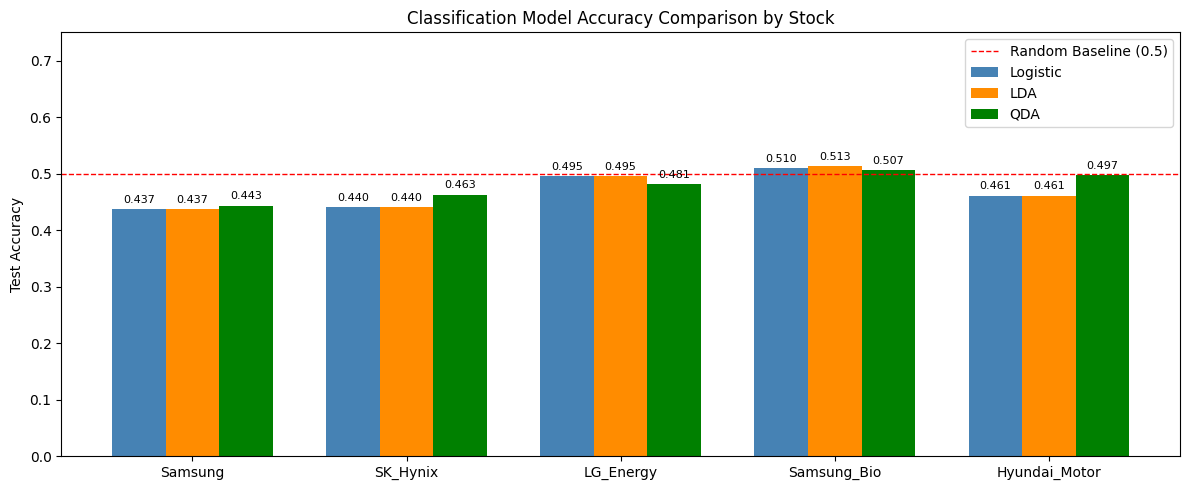

In [12]:
# ===== 모델 정확도 비교 시각화 =====
ticker_labels = list(prepared_data.keys())

# 각 모델의 테스트 정확도 재계산
logistic_acc = {}
for name, data in prepared_data.items():
    probs = logistic_results[name].predict(data['X_test_sm'])
    preds = np.where(probs > 0.5, 1, 0)
    logistic_acc[name] = np.mean(preds == data['y_test'])

x = np.arange(len(ticker_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, [logistic_acc[n] for n in ticker_labels], width, label='Logistic', color='steelblue')
bars2 = ax.bar(x,          [lda_accuracies[n] for n in ticker_labels],  width, label='LDA',      color='darkorange')
bars3 = ax.bar(x + width,  [qda_accuracies[n] for n in ticker_labels],  width, label='QDA',      color='green')

ax.set_ylabel('Test Accuracy')
ax.set_title('Classification Model Accuracy Comparison by Stock')
ax.set_xticks(x)
ax.set_xticklabels(ticker_labels)
ax.set_ylim(0, 0.75)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random Baseline (0.5)')
ax.legend()
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


## 교차 검증 (Cross-Validation)

Validation Set Approach는 데이터 분할 방식에 따라 결과가 달라질 수 있다. 수업 5장에서 배운 k-Fold Cross-Validation을 적용하여 모델의 일반화 성능을 보다 안정적으로 평가한다. sklearn의 cross_val_score를 사용해 5-Fold CV를 수행하고 평균 정확도와 표준편차를 확인한다.

===== 5-Fold Cross-Validation 결과 =====
[Samsung]
  Logistic CV Accuracy : 0.5175 +/- 0.0006
  LDA      CV Accuracy : 0.5194 +/- 0.0087
  QDA      CV Accuracy : 0.5149 +/- 0.0039
[SK_Hynix]
  Logistic CV Accuracy : 0.5156 +/- 0.0022
  LDA      CV Accuracy : 0.5091 +/- 0.0286
  QDA      CV Accuracy : 0.5208 +/- 0.0242
[LG_Energy]
  Logistic CV Accuracy : 0.5198 +/- 0.0018
  LDA      CV Accuracy : 0.5130 +/- 0.0219
  QDA      CV Accuracy : 0.5004 +/- 0.0301
[Samsung_Bio]
  Logistic CV Accuracy : 0.5471 +/- 0.0016
  LDA      CV Accuracy : 0.5471 +/- 0.0158
  QDA      CV Accuracy : 0.5307 +/- 0.0242
[Hyundai_Motor]
  Logistic CV Accuracy : 0.5312 +/- 0.0016
  LDA      CV Accuracy : 0.5227 +/- 0.0151
  QDA      CV Accuracy : 0.5312 +/- 0.0184


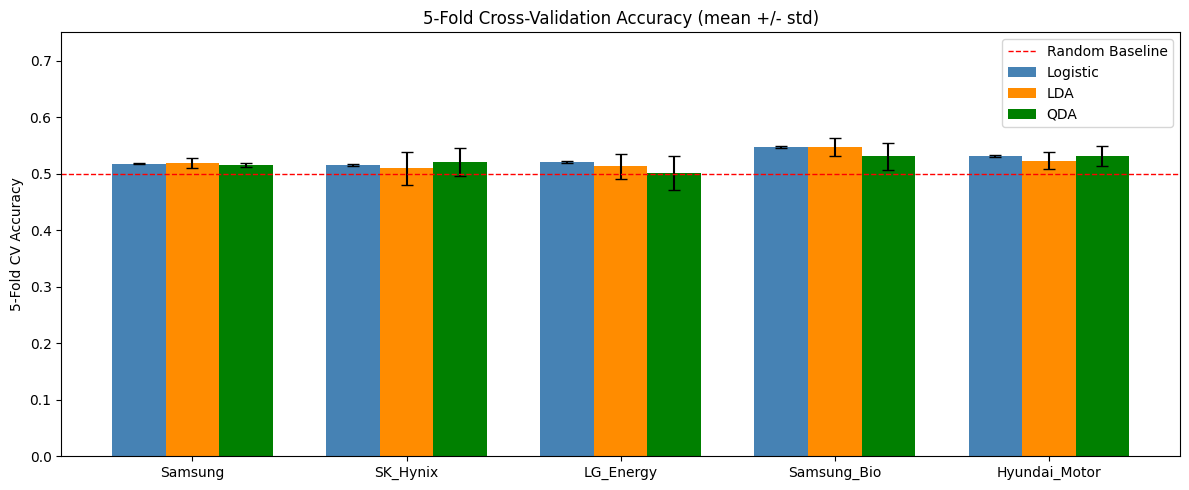

In [13]:
# ===== 5-Fold Cross-Validation (수업 Ch05 Resampling Methods 응용) =====
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=False)  # 시계열 순서 유지를 위해 shuffle=False

print("===== 5-Fold Cross-Validation 결과 =====")
cv_summary = {}

for name, df_clean in clean_stocks.items():
    X_cols = ['Lag1', 'Lag2']
    X_cv = df_clean[X_cols].values
    y_cv = df_clean['Direction'].values

    # Logistic CV
    logit_cv = LogisticRegression(max_iter=1000)
    logit_scores = cross_val_score(logit_cv, X_cv, y_cv, cv=cv, scoring='accuracy')

    # LDA CV
    lda_cv = LDA()
    lda_scores = cross_val_score(lda_cv, X_cv, y_cv, cv=cv, scoring='accuracy')

    # QDA CV
    qda_cv = QDA()
    qda_scores = cross_val_score(qda_cv, X_cv, y_cv, cv=cv, scoring='accuracy')

    cv_summary[name] = {
        'Logistic': (logit_scores.mean(), logit_scores.std()),
        'LDA':      (lda_scores.mean(),   lda_scores.std()),
        'QDA':      (qda_scores.mean(),   qda_scores.std()),
    }

    print(f"[{name}]")
    print(f"  Logistic CV Accuracy : {logit_scores.mean():.4f} +/- {logit_scores.std():.4f}")
    print(f"  LDA      CV Accuracy : {lda_scores.mean():.4f} +/- {lda_scores.std():.4f}")
    print(f"  QDA      CV Accuracy : {qda_scores.mean():.4f} +/- {qda_scores.std():.4f}")

# CV 결과 시각화
ticker_labels = list(cv_summary.keys())
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ticker_labels))
width = 0.25

logit_cv_means = [cv_summary[n]['Logistic'][0] for n in ticker_labels]
lda_cv_means   = [cv_summary[n]['LDA'][0]      for n in ticker_labels]
qda_cv_means   = [cv_summary[n]['QDA'][0]      for n in ticker_labels]
logit_cv_stds  = [cv_summary[n]['Logistic'][1] for n in ticker_labels]
lda_cv_stds    = [cv_summary[n]['LDA'][1]      for n in ticker_labels]
qda_cv_stds    = [cv_summary[n]['QDA'][1]      for n in ticker_labels]

ax.bar(x - width, logit_cv_means, width, yerr=logit_cv_stds, label='Logistic', color='steelblue',  capsize=4)
ax.bar(x,          lda_cv_means,   width, yerr=lda_cv_stds,   label='LDA',      color='darkorange', capsize=4)
ax.bar(x + width,  qda_cv_means,   width, yerr=qda_cv_stds,   label='QDA',      color='green',      capsize=4)

ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy (mean +/- std)')
ax.set_xticks(x)
ax.set_xticklabels(ticker_labels)
ax.set_ylim(0, 0.75)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random Baseline')
ax.legend()
plt.tight_layout()
plt.show()


## ROC Curve & AUC 비교 (삼성전자 대표)

분류 모델의 성능을 정확도 외에 ROC Curve와 AUC(Area Under Curve)로 시각화한다. AUC가 0.5에 가까울수록 랜덤 분류기와 다를 바 없으며, 1에 가까울수록 우수한 분류기이다. 삼성전자 종목을 대표로 3개 모델의 ROC를 비교한다.

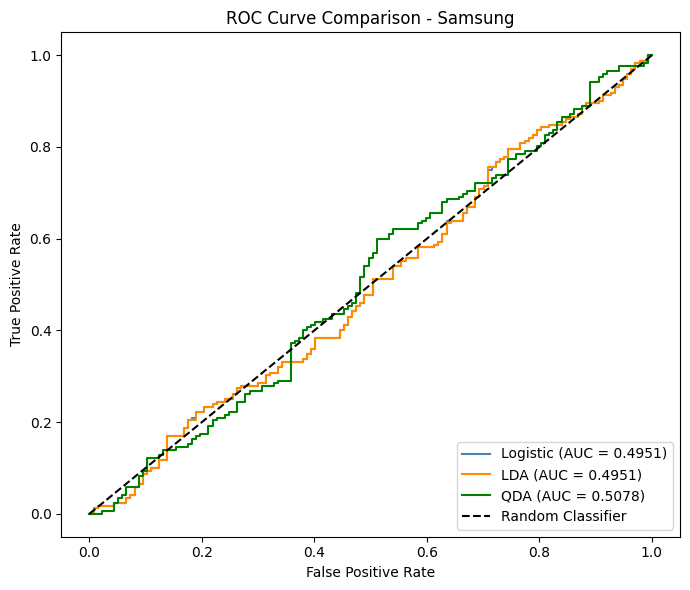

In [14]:
# ===== ROC Curve & AUC 비교 (삼성전자 대표) =====
from sklearn.metrics import roc_curve, auc

name = 'Samsung'
data = prepared_data[name]

# Logistic 확률값 (statsmodels predict는 pandas Series 반환)
probs_logit = logistic_results[name].predict(data['X_test_sm']).values

# LDA 확률값
lda_roc = LDA()
lda_roc.fit(data['X_train_sk'], data['y_train'])
probs_lda = lda_roc.predict_proba(data['X_test_sk'])[:, 1]

# QDA 확률값
qda_roc = QDA()
qda_roc.fit(data['X_train_sk'], data['y_train'])
probs_qda = qda_roc.predict_proba(data['X_test_sk'])[:, 1]

y_test_arr = data['y_test'].values

fig, ax = plt.subplots(figsize=(7, 6))

for probs, label, color in [
    (probs_logit, 'Logistic', 'steelblue'),
    (probs_lda,   'LDA',      'darkorange'),
    (probs_qda,   'QDA',      'green'),
]:
    fpr, tpr, _ = roc_curve(y_test_arr, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve Comparison - {name}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
